In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder ,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score



# load dataset

In [2]:
df = pd.read_csv("synthetic_health_dataset.csv")
df.head()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History,Illness
0,Fe__Male__,No,Moderate,Never,0Normal102,Borderline,High,"""90""",16.6,119,3.6,143.6,NaN,No,Yes
1,Other,Yes,NaN,Never,0Normal102,0Normal102,Low,20,29.9,69,9.9,121.8,NaN,Yes,No
2,__Male__,Yes,Heavy,Daily,High,High,Low,52,33.5,54,8.5,107,NaN,Yes,Yes
3,__Male__,Yes,Heavy,Daily,0Normal102,High,Low,15,20.3,72,9.5,92.1,NaN,No,Yes
4,__Male__,No,Moderate,Often,High,High,Medium,60,36.0,58,4.4,113.6,NaN,No,Yes


# DATA CLEANING

In [3]:
df.columns

Index(['Gender', 'Smoking', 'Alcohol_Consumption', 'Exercise_Frequency',
       'Blood_Pressure', 'Cholesterol_Level', 'Stress_Level', 'Age', 'BMI',
       'Heart_Rate', 'Sleep_Hours', 'Blood_Sugar_Level', 'Medication_Use',
       'Family_History', 'Illness'],
      dtype='object')

In [4]:
column_mapping = {
    'Gender': 'Gender',
    'Smoking': 'Smoking',
    'hol_Consump': 'Alcohol_Consumption',
    'rcise_Freque': 'Exercise_Frequency',
    'lood_Pressur': 'Blood_Pressure',
    'olesterol_Lev': 'Cholesterol_Level',
    'Stress_Level': 'Stress_Level',
    'Age': 'Age',
    'BMI': 'BMI',
    'Heart_Rate': 'Heart_Rate',
    'Sleep_Hours': 'Sleep_Hours',
    'od_Sugar_Leve': 'Blood_Sugar_Level',
    'edication_Usa': 'Medication_Usage',
    'amily_Histor': 'Family_History',
    'Illne': 'Illness'
}
df.rename(columns=column_mapping, inplace=True)

In [5]:
df.head()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History,Illness
0,Fe__Male__,No,Moderate,Never,0Normal102,Borderline,High,"""90""",16.6,119,3.6,143.6,NaN,No,Yes
1,Other,Yes,NaN,Never,0Normal102,0Normal102,Low,20,29.9,69,9.9,121.8,NaN,Yes,No
2,__Male__,Yes,Heavy,Daily,High,High,Low,52,33.5,54,8.5,107,NaN,Yes,Yes
3,__Male__,Yes,Heavy,Daily,0Normal102,High,Low,15,20.3,72,9.5,92.1,NaN,No,Yes
4,__Male__,No,Moderate,Often,High,High,Medium,60,36.0,58,4.4,113.6,NaN,No,Yes


In [6]:
df["Gender"].value_counts()

Gender
__Male__      336
Fe__Male__    326
Other         326
Name: count, dtype: int64

In [7]:
#  Clean string values in 'Gender' 
df['Gender'] = df['Gender'].astype(str).str.replace('__', '', regex=False)
df['Gender'] = df['Gender'].replace({'FeMale': 'Female', 'Male': 'Male', 'Other': 'Other', 'nan': np.nan})

In [8]:
df["Gender"].value_counts()

Gender
Male      336
Female    326
Other     326
Name: count, dtype: int64

In [9]:
df["Blood_Pressure"].value_counts()

Blood_Pressure
0Normal102    342
Low           336
High          312
Name: count, dtype: int64

In [10]:
df["Cholesterol_Level"].value_counts()

Cholesterol_Level
High          342
Borderline    340
0Normal102    311
Name: count, dtype: int64

In [11]:
df["Blood_Pressure"] = df["Blood_Pressure"].replace('0Normal102', 'Normal')
df["Cholesterol_Level"] = df["Cholesterol_Level"].replace('0Normal102', 'Normal')

In [12]:
df["Cholesterol_Level"].value_counts()

Cholesterol_Level
High          342
Borderline    340
Normal        311
Name: count, dtype: int64

#  Clean 'Age' column 

In [13]:
#  Clean 'Age' column 
df['Age'] = df['Age'].astype(str).str.replace('"', '', regex=False).str.replace("'", "", regex=False)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [14]:
df["Age"].dtype

dtype('float64')

In [15]:
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')
df['Blood_Sugar_Level'] = pd.to_numeric(df['Blood_Sugar_Level'], errors='coerce')

In [16]:
df["Medication_Use"].value_counts()

Medication_Use
Occasional       344
Regular          308
Regular____        2
Occasional___      1
Name: count, dtype: int64

In [17]:
df['Medication_Use'] = df['Medication_Use'].astype(str).str.rstrip('_')
df['Medication_Use'] = df['Medication_Use'].replace('nan', np.nan)

#  Fill the missing values with the most common category (Mode)
med_mode = df['Medication_Use'].mode()[0]
df['Medication_Use'] = df['Medication_Use'].fillna(med_mode)

In [18]:
df["Medication_Use"].value_counts()

Medication_Use
Occasional    690
Regular       310
Name: count, dtype: int64

In [19]:
df["Exercise_Frequency"].value_counts()

Exercise_Frequency
Never     258
Daily     248
Often     248
Rarely    239
Name: count, dtype: int64

In [20]:
df.nunique()

Gender                   3
Smoking                  2
Alcohol_Consumption      2
Exercise_Frequency       4
Blood_Pressure           3
Cholesterol_Level        3
Stress_Level             3
Age                    100
BMI                    248
Heart_Rate              69
Sleep_Hours             71
Blood_Sugar_Level      661
Medication_Use           2
Family_History           2
Illness                  2
dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               988 non-null    object 
 1   Smoking              993 non-null    object 
 2   Alcohol_Consumption  649 non-null    object 
 3   Exercise_Frequency   993 non-null    object 
 4   Blood_Pressure       990 non-null    object 
 5   Cholesterol_Level    993 non-null    object 
 6   Stress_Level         995 non-null    object 
 7   Age                  990 non-null    float64
 8   BMI                  992 non-null    float64
 9   Heart_Rate           977 non-null    float64
 10  Sleep_Hours          992 non-null    float64
 11  Blood_Sugar_Level    978 non-null    float64
 12  Medication_Use       1000 non-null   object 
 13  Family_History       995 non-null    object 
 14  Illness              1000 non-null   object 
dtypes: float64(5), object(10)
memory usage:

In [22]:
df.duplicated().sum()


np.int64(0)

In [23]:
df.isna().sum()

Gender                  12
Smoking                  7
Alcohol_Consumption    351
Exercise_Frequency       7
Blood_Pressure          10
Cholesterol_Level        7
Stress_Level             5
Age                     10
BMI                      8
Heart_Rate              23
Sleep_Hours              8
Blood_Sugar_Level       22
Medication_Use           0
Family_History           5
Illness                  0
dtype: int64

In [24]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("🤖  Numerical :", numerical_cols)
print("🤖  Categorical :", categorical_cols)

🤖  Numerical : ['Age', 'BMI', 'Heart_Rate', 'Sleep_Hours', 'Blood_Sugar_Level']
🤖  Categorical : ['Gender', 'Smoking', 'Alcohol_Consumption', 'Exercise_Frequency', 'Blood_Pressure', 'Cholesterol_Level', 'Stress_Level', 'Medication_Use', 'Family_History', 'Illness']


In [25]:
# Fill all detected numerical columns with their respective Medians
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill all detected categorical columns with their respective Modes
for col in categorical_cols:
    # Ensure there is a mode available to prevent crashes on completely empty columns
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

In [26]:
df.isnull().sum()

Gender                 0
Smoking                0
Alcohol_Consumption    0
Exercise_Frequency     0
Blood_Pressure         0
Cholesterol_Level      0
Stress_Level           0
Age                    0
BMI                    0
Heart_Rate             0
Sleep_Hours            0
Blood_Sugar_Level      0
Medication_Use         0
Family_History         0
Illness                0
dtype: int64

# Encoding

In [27]:
# 1. Find all columns that are still text/object type
categorical_cols = df.select_dtypes(include=['object']).columns

# 2. Apply LabelEncoder to each of them
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Preview the completely numeric dataset
df.head()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History,Illness
0,0,0,1,1,2,0,0,90.0,16.6,119.0,3.6,143.6,0,0,1
1,2,1,1,1,2,2,1,20.0,29.9,69.0,9.9,121.8,0,1,0
2,1,1,0,0,0,1,1,52.0,33.5,54.0,8.5,107.0,0,1,1
3,1,1,0,0,2,1,1,15.0,20.3,72.0,9.5,92.1,0,0,1
4,1,0,1,2,0,1,2,60.0,36.0,58.0,4.4,113.6,0,0,1


In [28]:
df.corr()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History,Illness
Gender,1.000000,-0.004957,0.037390,-0.050383,0.019782,-0.036862,-0.042099,-0.041293,0.091444,-0.031075,-0.024167,0.004913,0.018744,0.064432,-0.054502
Smoking,-0.004957,1.000000,-0.007859,-0.014245,0.009048,0.000017,-0.019171,-0.004534,0.034312,-0.043070,0.020960,-0.013936,-0.016139,-0.015104,-0.026701
Alcohol_Consumption,0.037390,-0.007859,1.000000,-0.033896,-0.022469,0.021190,-0.018848,0.034261,-0.049361,-0.007201,0.013701,0.009898,0.023454,-0.028083,0.018852
Exercise_Frequency,-0.050383,-0.014245,-0.033896,1.000000,0.010975,-0.011367,0.029628,-0.035734,0.007177,-0.015199,0.012422,0.016986,-0.012080,-0.038627,-0.022100
Blood_Pressure,0.019782,0.009048,-0.022469,0.010975,1.000000,0.007863,-0.032936,0.037271,-0.013176,-0.000882,-0.019087,-0.050772,-0.022316,-0.013178,0.013272
Cholesterol_Level,-0.036862,0.000017,0.021190,-0.011367,0.007863,1.000000,0.017064,0.039467,-0.020709,-0.043821,-0.023479,0.024833,-0.021479,-0.017282,0.010445
Stress_Level,-0.042099,-0.019171,-0.018848,0.029628,-0.032936,0.017064,1.000000,-0.008882,-0.009171,-0.024002,0.059568,-0.033830,-0.046909,0.051337,0.022513
Age,-0.041293,-0.004534,0.034261,-0.035734,0.037271,0.039467,-0.008882,1.000000,-0.019265,-0.007679,-0.034925,-0.046519,0.005209,-0.042467,0.021581
BMI,0.091444,0.034312,-0.049361,0.007177,-0.013176,-0.020709,-0.009171,-0.019265,1.000000,-0.023578,0.002878,0.033677,0.028754,0.037044,0.044299
Heart_Rate,-0.031075,-0.043070,-0.007201,-0.015199,-0.000882,-0.043821,-0.024002,-0.007679,-0.023578,1.000000,-0.011350,-0.022566,-0.016643,0.042542,0.037682


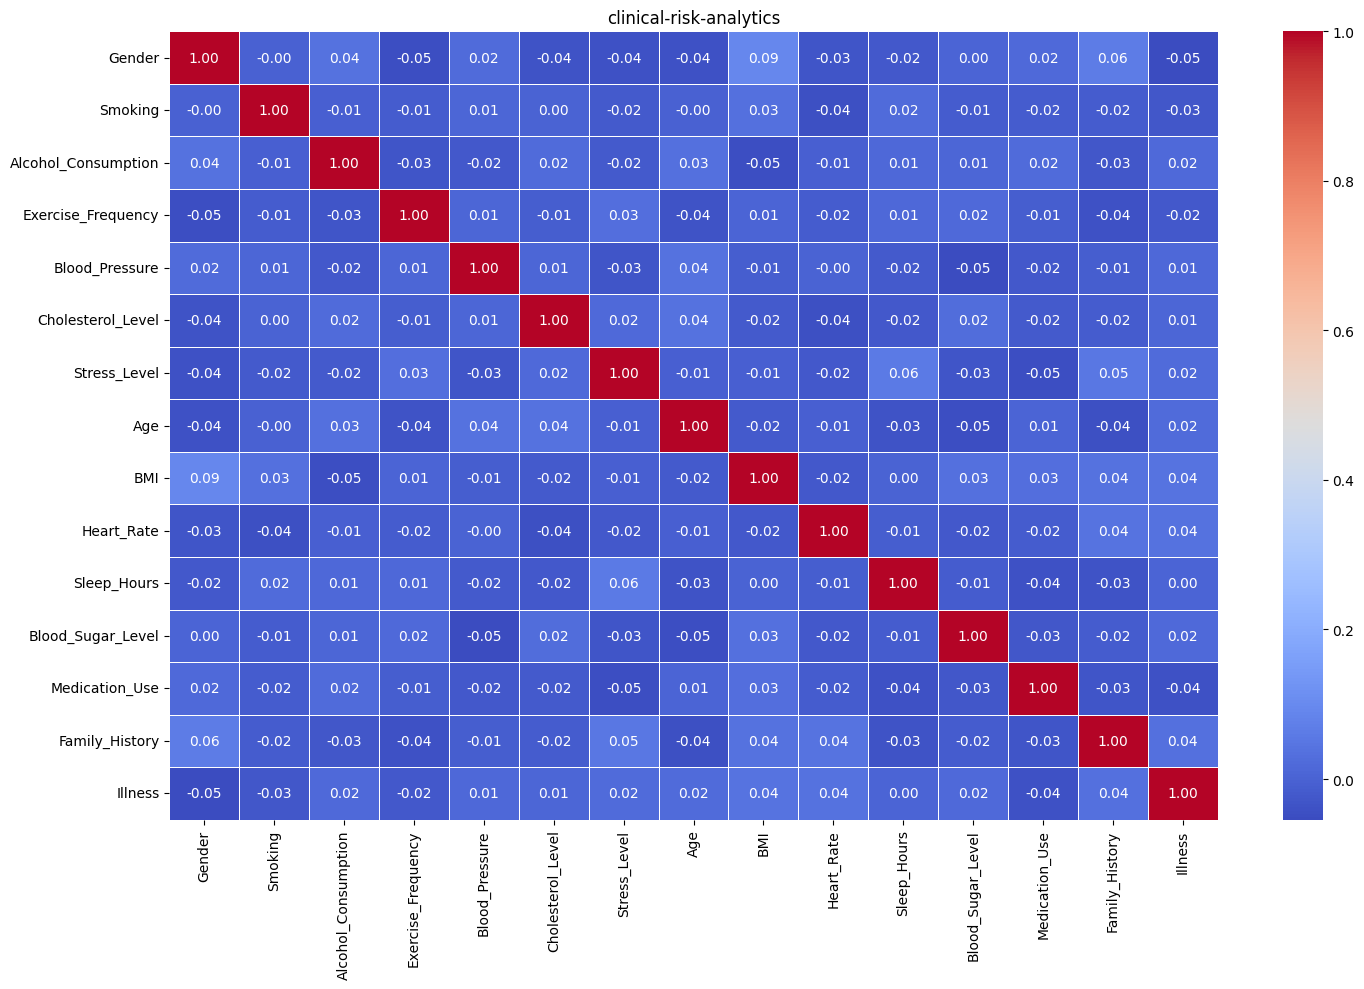

In [29]:

# 1. Set the figure size BEFORE creating the plot
plt.figure(figsize=(15, 10))

# 2. Use your correlation matrix (replace df.corr() if needed)
# annot=True shows the values, fmt=".2f" keeps them at 2 decimal places
# cmap='coolwarm' is a standard color palette for correlations
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Add titles and labels
plt.title('clinical-risk-analytics')

# 4. Display the plot
plt.tight_layout() # Ensures the labels aren't cut off
plt.show()

In [30]:
df.describe()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History,Illness
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1.000000,0.483000,0.687000,1.47800,1.040000,0.971000,0.977000,49.532000,27.406000,84.961000,6.585600,135.741500,0.310000,0.484000,0.49000
std,0.807869,0.499961,0.463946,1.10668,0.814287,0.806728,0.824106,28.685987,7.206546,20.135862,2.030309,36.455053,0.462725,0.499994,0.50015
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,15.100000,50.000000,3.000000,70.200000,0.000000,0.000000,0.00000
25%,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,24.000000,21.100000,68.000000,4.800000,106.175000,0.000000,0.000000,0.00000
50%,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.000000,50.000000,27.350000,84.000000,6.600000,136.550000,0.000000,0.000000,0.00000
75%,2.000000,1.000000,1.000000,2.00000,2.000000,2.000000,2.000000,75.000000,33.525000,103.000000,8.400000,167.450000,1.000000,1.000000,1.00000
max,2.000000,1.000000,1.000000,3.00000,2.000000,2.000000,2.000000,99.000000,40.000000,119.000000,10.000000,200.000000,1.000000,1.000000,1.00000


<Axes: ylabel='Illness'>

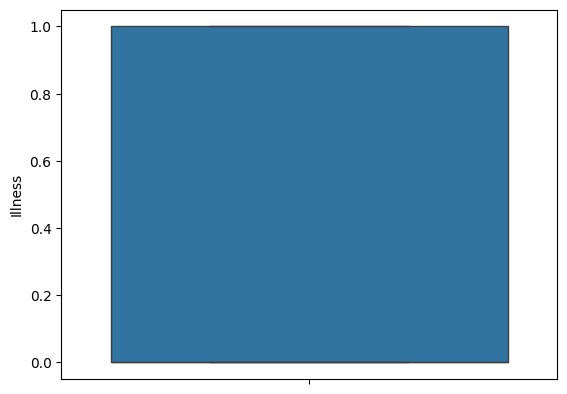

In [31]:
sns.boxplot(df["Illness"])

# re asambled dependent and independent variables

In [32]:
x = df.drop(columns=["Illness"])
y = df["Illness"]

In [33]:
x.head()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History
0,0,0,1,1,2,0,0,90.0,16.6,119.0,3.6,143.6,0,0
1,2,1,1,1,2,2,1,20.0,29.9,69.0,9.9,121.8,0,1
2,1,1,0,0,0,1,1,52.0,33.5,54.0,8.5,107.0,0,1
3,1,1,0,0,2,1,1,15.0,20.3,72.0,9.5,92.1,0,0
4,1,0,1,2,0,1,2,60.0,36.0,58.0,4.4,113.6,0,0


In [34]:
print(x.shape)
print(y.shape)

(1000, 14)
(1000,)


In [35]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [36]:
print(xtrain.shape, xtest.shape )
print(ytrain.shape, ytest.shape)

(800, 14) (200, 14)
(800,) (200,)


In [37]:
scaler = StandardScaler()

xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

# Logistic Regression

In [38]:
lr = LogisticRegression()


In [39]:
model1 = lr.fit(xtrain, ytrain)

In [40]:
model1.score(xtrain, ytrain)

0.5825

In [41]:
model1.score(xtest ,ytest)

0.46

In [42]:
pred1 = model1.predict(xtest)
pred1

array([0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0])

In [43]:
cls_repo1 = classification_report(ytest, pred1)
print(cls_repo1)

              precision    recall  f1-score   support

           0       0.48      0.46      0.47       105
           1       0.44      0.46      0.45        95

    accuracy                           0.46       200
   macro avg       0.46      0.46      0.46       200
weighted avg       0.46      0.46      0.46       200



# Random Forest

In [44]:
rf = RandomForestClassifier()

In [45]:
model2 = rf.fit(xtrain, ytrain)
model2.score(xtrain, ytrain)

1.0

In [46]:
model2.score(xtest, ytest)

0.44

In [47]:
pred2 = model2.predict(xtest)
pred2

array([1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0])

In [48]:
cls_repo2 = classification_report(ytest, pred2)
print(cls_repo2)

              precision    recall  f1-score   support

           0       0.47      0.50      0.49       105
           1       0.40      0.37      0.38        95

    accuracy                           0.44       200
   macro avg       0.44      0.44      0.44       200
weighted avg       0.44      0.44      0.44       200



# Decision Tree

In [49]:
dt = DecisionTreeClassifier()

In [50]:
model3 = dt.fit(xtrain, ytrain)
model3.score(xtrain, ytrain)

1.0

In [51]:
model3.score(xtest, ytest)

0.485

In [52]:
pred3 = model3.predict(xtest)
pred3

array([0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1])

In [53]:
cls_repo3 = classification_report(ytest, pred3)
print(cls_repo3)

              precision    recall  f1-score   support

           0       0.51      0.45      0.48       105
           1       0.46      0.53      0.49        95

    accuracy                           0.48       200
   macro avg       0.49      0.49      0.48       200
weighted avg       0.49      0.48      0.48       200



# S V  M

In [54]:
svm = SVC(
    kernel='rbf',          # 'rbf' is usually best
    C=1.0,                 # Regularization parameter
    gamma='scale',         # 'scale' or 'auto'
    probability=True,      # Needed for ROC-AUC
    random_state=42,
    class_weight='balanced'  # Good if classes are imbalanced
)

In [55]:
model4 = svm.fit(xtrain, ytrain)
model4.score(xtrain, ytrain)

0.7675

In [56]:
model4.score(xtest, ytest)

0.435

In [57]:
pred4 = model4.predict(xtest)


In [58]:
cls_repo4 = classification_report(ytest, pred4)
print(cls_repo4)

              precision    recall  f1-score   support

           0       0.46      0.44      0.45       105
           1       0.41      0.43      0.42        95

    accuracy                           0.43       200
   macro avg       0.43      0.43      0.43       200
weighted avg       0.44      0.43      0.44       200



# XGBoost

In [59]:
xgb = XGBClassifier()


In [60]:
model5 = xgb.fit(xtrain , ytrain)
model5.score(xtrain, ytrain)

1.0

In [61]:
model5.score(xtest, ytest)

0.47

In [66]:
pred5 = model5.predict(xtest)

In [67]:
cls_repo5 = classification_report(ytest, pred5)
print(cls_repo5)

              precision    recall  f1-score   support

           0       0.50      0.48      0.49       105
           1       0.44      0.46      0.45        95

    accuracy                           0.47       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.47      0.47      0.47       200



# Cat Boost 

In [64]:
cb = CatBoostClassifier()

In [68]:
model6 = xgb.fit(xtrain , ytrain)
model6.score(xtrain, ytrain)

1.0

In [69]:
model6.score(xtest, ytest)

0.47

In [70]:
pred6 = model6.predict(xtest)

In [71]:
cls_repo6 = classification_report(ytest, pred6)
print(cls_repo6)

              precision    recall  f1-score   support

           0       0.50      0.48      0.49       105
           1       0.44      0.46      0.45        95

    accuracy                           0.47       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.47      0.47      0.47       200



In [ ]:
model5 = xgb.fit(xtrain , ytrain)
model5.score(xtrain, ytrain)

In [ ]:
model5.score(xtest, ytest)

In [ ]:
pred5 = model5.predict(xtest)

In [ ]:
cls_repo5 = classification_report(ytest, pred4)
print(cls_repo5)